In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

In [3]:
curr_dir_path = os.getcwd()
main_dir_path = os.path.abspath(os.path.join(curr_dir_path, os.pardir))
data_dir_path = os.path.join(main_dir_path, 'data')
raw_data_dir_path = os.path.join(data_dir_path, 'raw_data')
processed_data_dir_path = os.path.join(data_dir_path, 'processed_data')
cw_dir_path = os.path.join(data_dir_path, 'cw')
emissions_data_dir_path = os.path.join(raw_data_dir_path, 'emissions_data')
iea_data_dir_path = os.path.join(raw_data_dir_path, 'IEA_climate_policy_data')

In [4]:
emissions_total_df = pd.read_csv(os.path.join(processed_data_dir_path, 'total_emissions_with_policies.csv'))
agg_policies_emissions_df = pd.read_csv(os.path.join(processed_data_dir_path, 'agg_policies_and_emissions_data_by_country.csv'))

In [5]:
emissions_total_df

,iso3,year,country,policies_per_year,policies_last_5_years,income_group,prev_year_emission,avg_emissions_prev_3_years,total_emissions
0,AFG,2000,Afghanistan,0,0.0,Low income,NaN,NaN,25.390391
1,AFG,2001,Afghanistan,0,0.0,Low income,25.390391,25.390391,23.723115
2,AFG,2002,Afghanistan,0,0.0,Low income,23.723115,24.556753,26.383509
3,AFG,2003,Afghanistan,0,0.0,Low income,26.383509,25.165672,27.071538
4,AFG,2004,Afghanistan,0,0.0,Low income,27.071538,25.726054,27.128799
...,...,...,...,...,...,...,...,...,...
4365,ZWE,2018,Zimbabwe,0,1.0,Lower middle income,45.410983,46.390136,47.509033
4366,ZWE,2019,Zimbabwe,1,0.0,Lower middle income,47.509033,46.277579,46.442562
4367,ZWE,2020,Zimbabwe,0,1.0,Lower middle income,46.442562,46.454193,44.576343
4368,ZWE,2021,Zimbabwe,1,1.0,Lower middle income,44.576343,46.175979,45.759664


In [6]:
agg_policies_emissions_df.head()

,iso3,country,income_group,avg_emissions,avg_policies_last_5_years,emission_pct_change,emission_change
0,AFG,Afghanistan,Low income,34.967808,0.391304,0.514646,13.067067
1,AGO,Angola,Lower middle income,130.803111,4.739130,0.227446,25.365705
2,ALB,Albania,Upper middle income,9.892394,2.304348,0.073085,0.630193
3,ARE,United Arab Emirates,High income,211.977407,6.565217,1.428248,168.617154
4,ARG,Argentina,Upper middle income,424.588736,10.608696,0.086533,33.628259


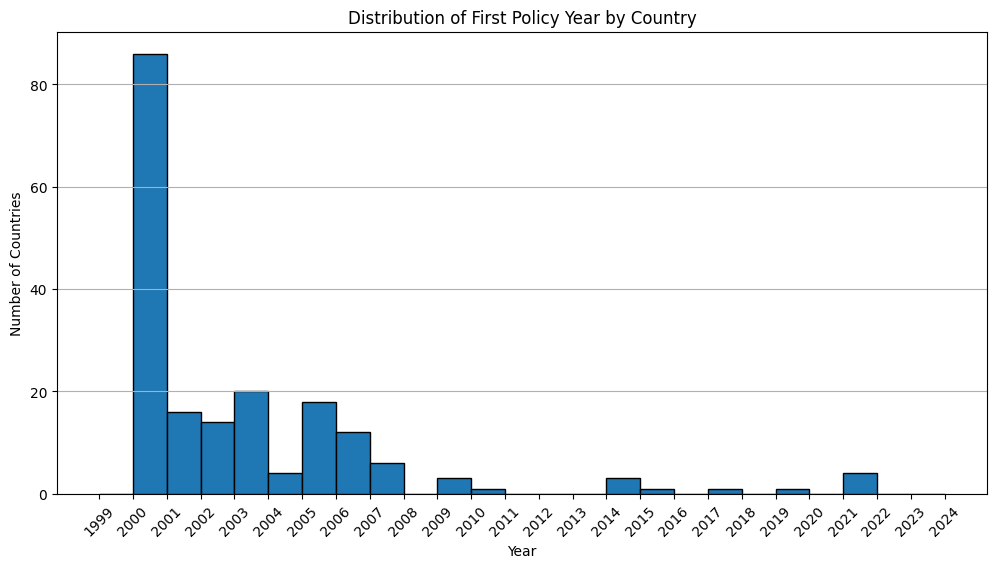

In [9]:
# Filter the rows where a policy was implemented (policies_per_year > 0)
df_policy = emissions_total_df[emissions_total_df['policies_per_year'] > 0]

# Group by country (using iso3 and country as identifiers) to find the first policy year per country
first_policy_df = df_policy.groupby(['iso3', 'country'], as_index=False)['year'].min()
first_policy_df = first_policy_df.rename(columns={'year': 'first_policy_year'})

# Sort the dataframe by the first policy year (optional, for better visualization)
first_policy_df = first_policy_df.sort_values('first_policy_year')

# Plot an histogram
plt.figure(figsize=(12, 6))
plt.hist(first_policy_df['first_policy_year'], bins=range(1999, 2025), edgecolor='black')
plt.title('Distribution of First Policy Year by Country')
plt.xlabel('Year')
plt.ylabel('Number of Countries')
plt.xticks(range(1999, 2025), rotation=45)
plt.grid(axis='y')


## Cleaning

In [187]:
# Drop unnecessary columns
emissions_total_df.drop(columns=['policies_per_year'], inplace=True)

In [188]:
# Check for missing values
missing_values = emissions_total_df.isnull().sum()
print("Missing values in emissions_total_df:")
print(missing_values[missing_values > 0])

# Check for missing values in agg_policies_emissions_df
missing_values = agg_policies_emissions_df.isnull().sum()
print("Missing values in agg_policies_emissions_df:")
print(missing_values[missing_values > 0])


Missing values in emissions_total_df:
prev_year_emission            190
avg_emissions_prev_3_years    190
dtype: int64
Missing values in agg_policies_emissions_df:
Series([], dtype: int64)


In [189]:
# Drop null values in total emissions DataFrame
emissions_total_df.dropna(inplace=True)

# Reset index
emissions_total_df.reset_index(drop=True, inplace=True)

## EDA

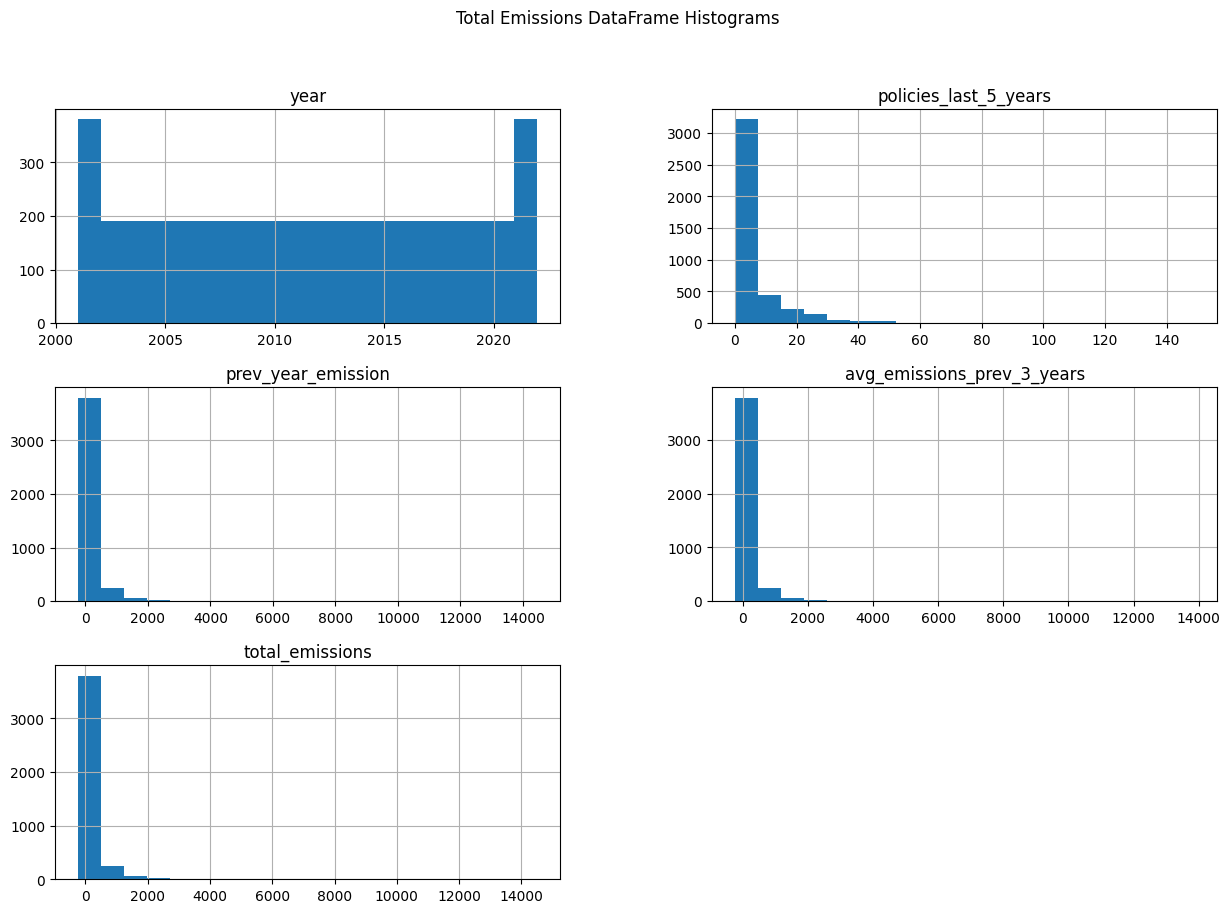

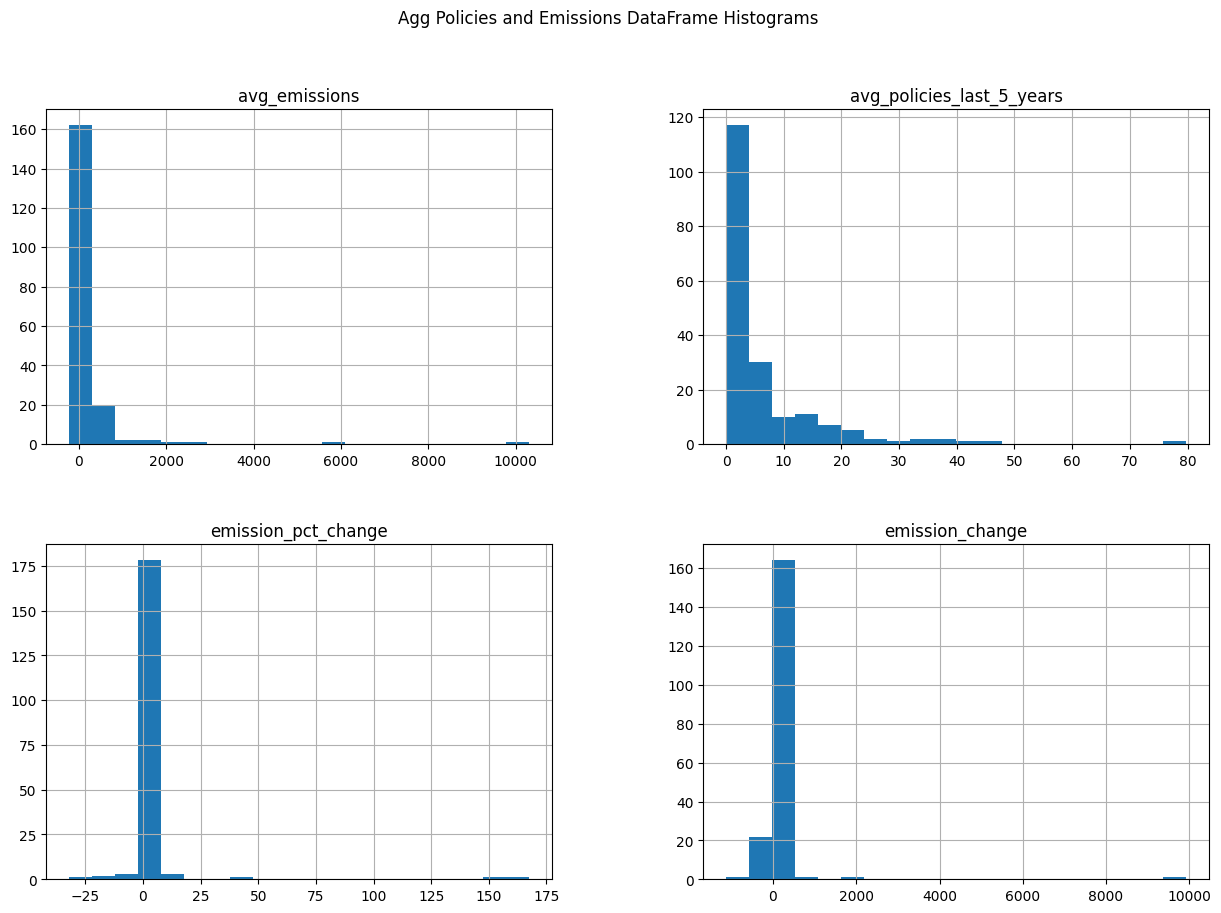

In [190]:
# Plot histograms of numeric columns
def plot_histograms(df, title):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols].hist(bins=20, figsize=(15, 10))
    plt.suptitle(title)
    plt.show()

plot_histograms(emissions_total_df, 'Total Emissions DataFrame Histograms')
plot_histograms(agg_policies_emissions_df, 'Agg Policies and Emissions DataFrame Histograms')

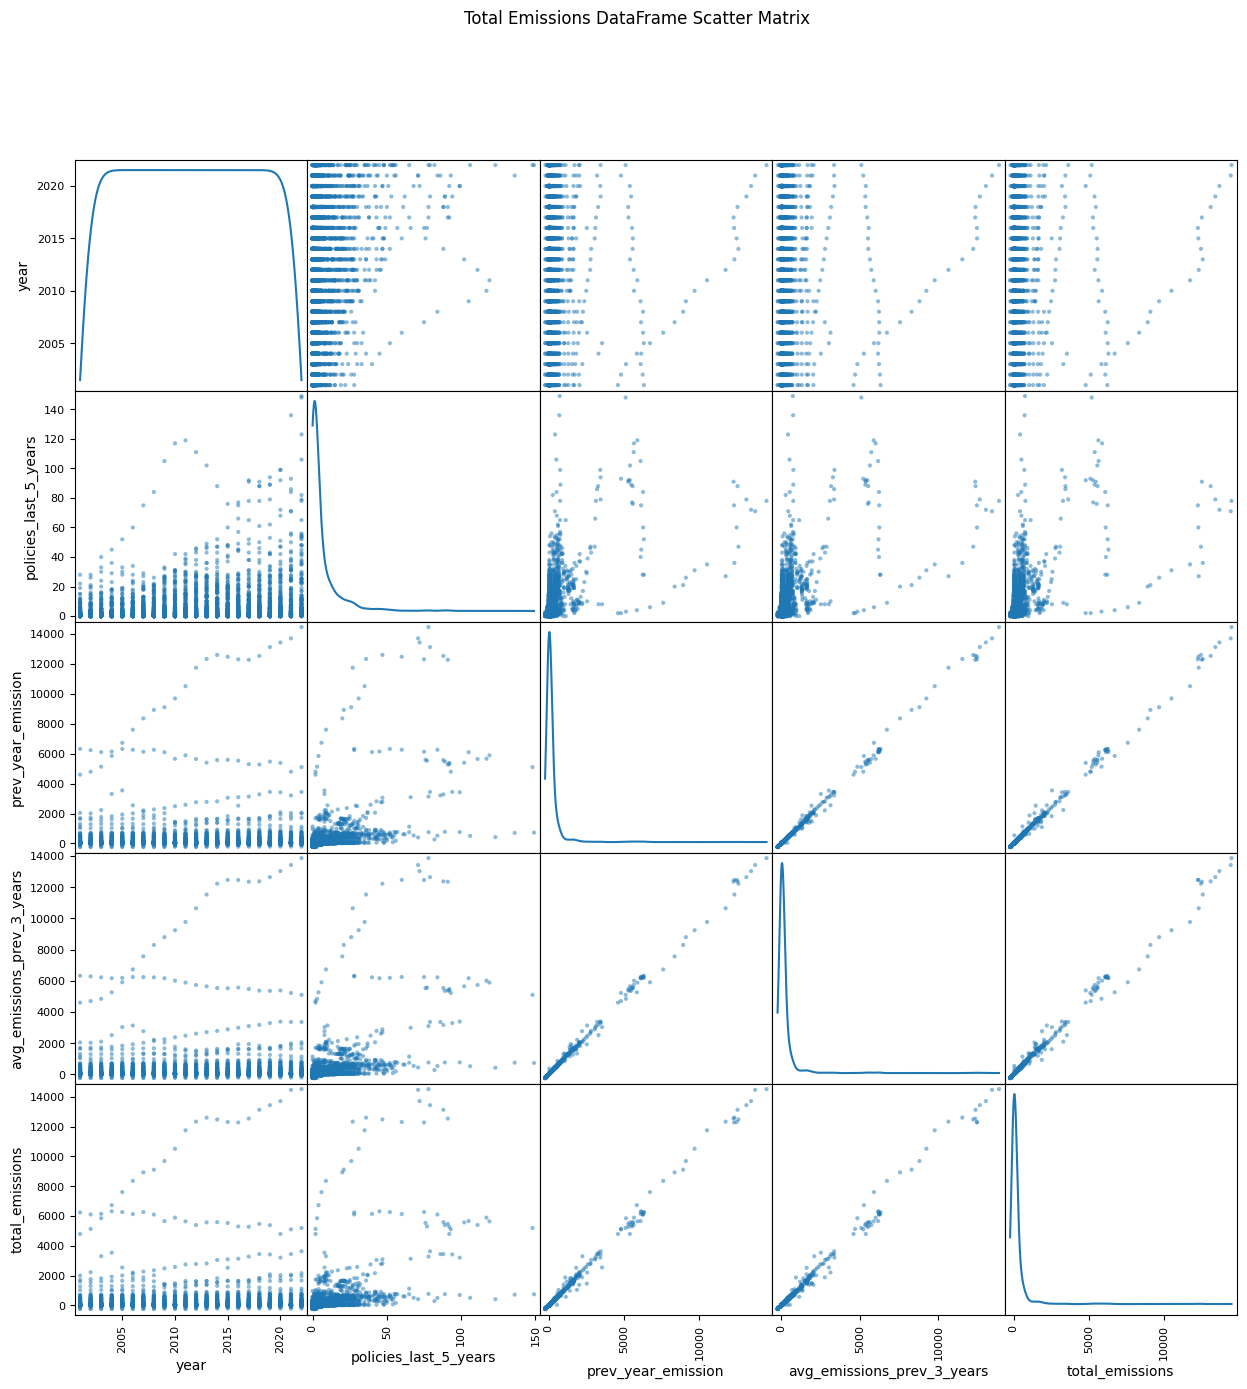

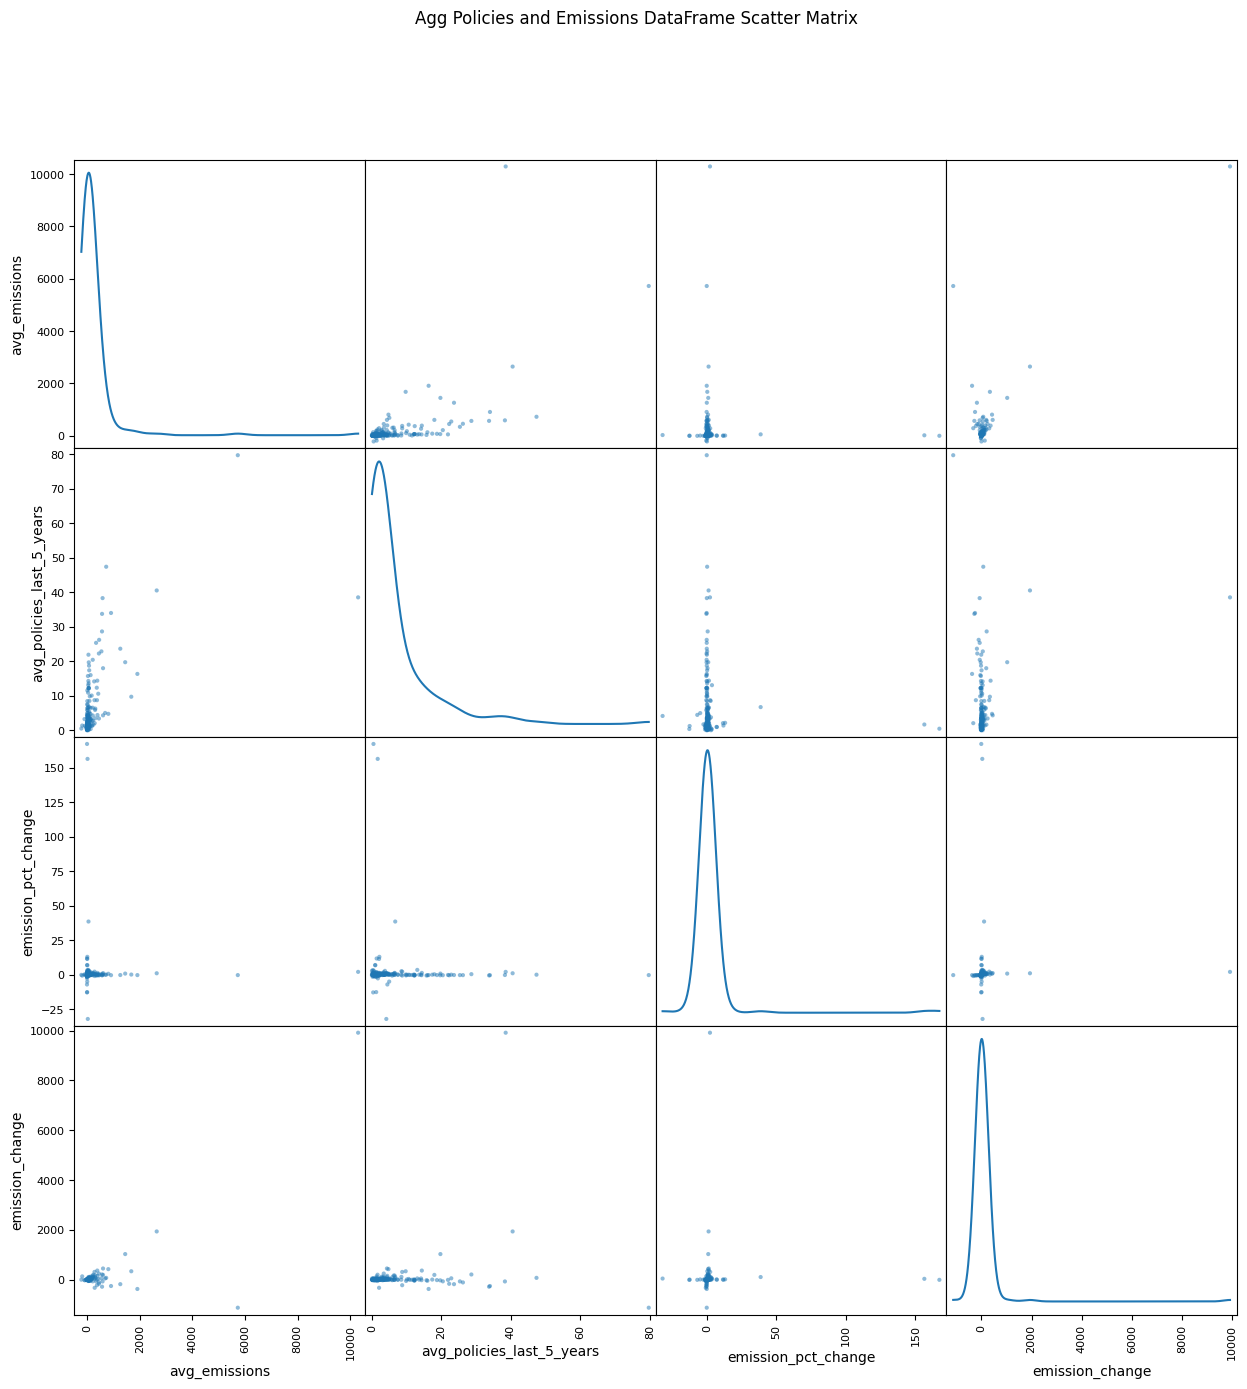

In [191]:
# Plot scatter plots of numeric columns
def plot_scatter_matrix(df, title):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    pd.plotting.scatter_matrix(df[numeric_cols], figsize=(15, 15), diagonal='kde')
    plt.suptitle(title)
    plt.show()
plot_scatter_matrix(emissions_total_df, 'Total Emissions DataFrame Scatter Matrix')
plot_scatter_matrix(agg_policies_emissions_df, 'Agg Policies and Emissions DataFrame Scatter Matrix')


In [192]:
agg_policies_emissions_df.sort_values(by='emission_pct_change', ascending=False, inplace=True)
agg_policies_emissions_df.reset_index(drop=True, inplace=True)

# Add rank column
agg_policies_emissions_df['rank_pct'] = agg_policies_emissions_df.index + 1
agg_policies_emissions_df.head()

,iso3,country,income_group,avg_emissions,avg_policies_last_5_years,emission_pct_change,emission_change,rank_pct
0,DMA,Dominica,Upper middle income,-1.021640,0.478261,167.292001,-2.599087,1
1,MNG,Mongolia,Lower middle income,17.703677,1.695652,156.470579,37.913701,2
2,MYS,Malaysia,Upper middle income,53.847368,6.739130,38.630843,109.399556,3
3,SEN,Senegal,Lower middle income,9.041215,2.173913,13.051951,17.289837,4
4,SYC,Seychelles,High income,0.207767,1.391304,11.846501,0.345386,5


In [193]:
agg_policies_emissions_df.sort_values(by='emission_change', ascending=False, inplace=True)
agg_policies_emissions_df.reset_index(drop=True, inplace=True)

# Add rank column
agg_policies_emissions_df['rank_absolute'] = agg_policies_emissions_df.index + 1
agg_policies_emissions_df.head()

,iso3,country,income_group,avg_emissions,avg_policies_last_5_years,emission_pct_change,emission_change,rank_pct,rank_absolute
0,CHN,People's Republic of China,Upper middle income,10294.699549,38.521739,2.156335,9913.731419,17,1
1,IND,India,Lower middle income,2644.678008,40.521739,1.144481,1938.873699,30,2
2,IDN,Indonesia,Upper middle income,1448.021164,19.739130,0.908809,1031.087643,41,3
3,SAU,Saudi Arabia,High income,606.654647,4.347826,1.294496,452.205666,27,4
4,IRN,Islamic Republic of Iran,Lower middle income,807.601288,4.782609,0.779527,426.383361,52,5


In [194]:
# Get top 50 countries with the highest and lowest avg emissions
top_emitter_countries = agg_policies_emissions_df.sort_values(by='avg_emissions', ascending=False).head(50)

# Reset index
top_emitter_countries.reset_index(drop=True, inplace=True)
top_emitter_countries.head()

,iso3,country,income_group,avg_emissions,avg_policies_last_5_years,emission_pct_change,emission_change,rank_pct,rank_absolute
0,CHN,People's Republic of China,Upper middle income,10294.699549,38.521739,2.156335,9913.731419,17,1
1,USA,United States,High income,5724.806851,79.695652,-0.177442,-1121.186369,147,190
2,IND,India,Lower middle income,2644.678008,40.521739,1.144481,1938.873699,30,2
3,BRA,Brazil,Upper middle income,1910.755268,16.347826,-0.180563,-369.285510,149,189
4,RUS,Russian Federation,Upper middle income,1679.563796,9.739130,0.208954,341.217786,100,7


In [195]:
top_policy_makers = agg_policies_emissions_df.sort_values(by='avg_policies_last_5_years', ascending=False).head(50)

# Reset index
top_policy_makers.reset_index(drop=True, inplace=True)
top_policy_makers.head()

,iso3,country,income_group,avg_emissions,avg_policies_last_5_years,emission_pct_change,emission_change,rank_pct,rank_absolute
0,USA,United States,High income,5724.806851,79.695652,-0.177442,-1121.186369,147,190
1,CAN,Canada,High income,726.135085,47.391304,0.114473,76.954151,108,25
2,IND,India,Lower middle income,2644.678008,40.521739,1.144481,1938.873699,30,2
3,CHN,People's Republic of China,Upper middle income,10294.699549,38.521739,2.156335,9913.731419,17,1
4,AUS,Australia,High income,589.449485,38.304348,-0.115993,-67.440656,141,181


In [196]:
top_reduction_countries = agg_policies_emissions_df.sort_values(by='emission_change', ascending=False).head(50)
# Reset index
top_reduction_countries.reset_index(drop=True, inplace=True)
top_reduction_countries.head()

,iso3,country,income_group,avg_emissions,avg_policies_last_5_years,emission_pct_change,emission_change,rank_pct,rank_absolute
0,CHN,People's Republic of China,Upper middle income,10294.699549,38.521739,2.156335,9913.731419,17,1
1,IND,India,Lower middle income,2644.678008,40.521739,1.144481,1938.873699,30,2
2,IDN,Indonesia,Upper middle income,1448.021164,19.739130,0.908809,1031.087643,41,3
3,SAU,Saudi Arabia,High income,606.654647,4.347826,1.294496,452.205666,27,4
4,IRN,Islamic Republic of Iran,Lower middle income,807.601288,4.782609,0.779527,426.383361,52,5


In [197]:
# Merge top emitters with top policy makers
merge_df = pd.merge(top_emitter_countries, top_policy_makers, on='country')
best_countries = merge_df['iso3_x'].tolist()
len(best_countries)

28

In [198]:
# Filter the DataFrame to include only the best countries
best_countries_df = agg_policies_emissions_df[agg_policies_emissions_df['iso3'].isin(best_countries)]
# Reset index
best_countries_df.reset_index(drop=True, inplace=True)
best_countries_df.head()

,iso3,country,income_group,avg_emissions,avg_policies_last_5_years,emission_pct_change,emission_change,rank_pct,rank_absolute
0,CHN,People's Republic of China,Upper middle income,10294.699549,38.521739,2.156335,9913.731419,17,1
1,IND,India,Lower middle income,2644.678008,40.521739,1.144481,1938.873699,30,2
2,IDN,Indonesia,Upper middle income,1448.021164,19.739130,0.908809,1031.087643,41,3
3,TUR,Turkiye,Upper middle income,388.202551,14.391304,1.414567,369.036863,25,6
4,RUS,Russian Federation,Upper middle income,1679.563796,9.739130,0.208954,341.217786,100,7


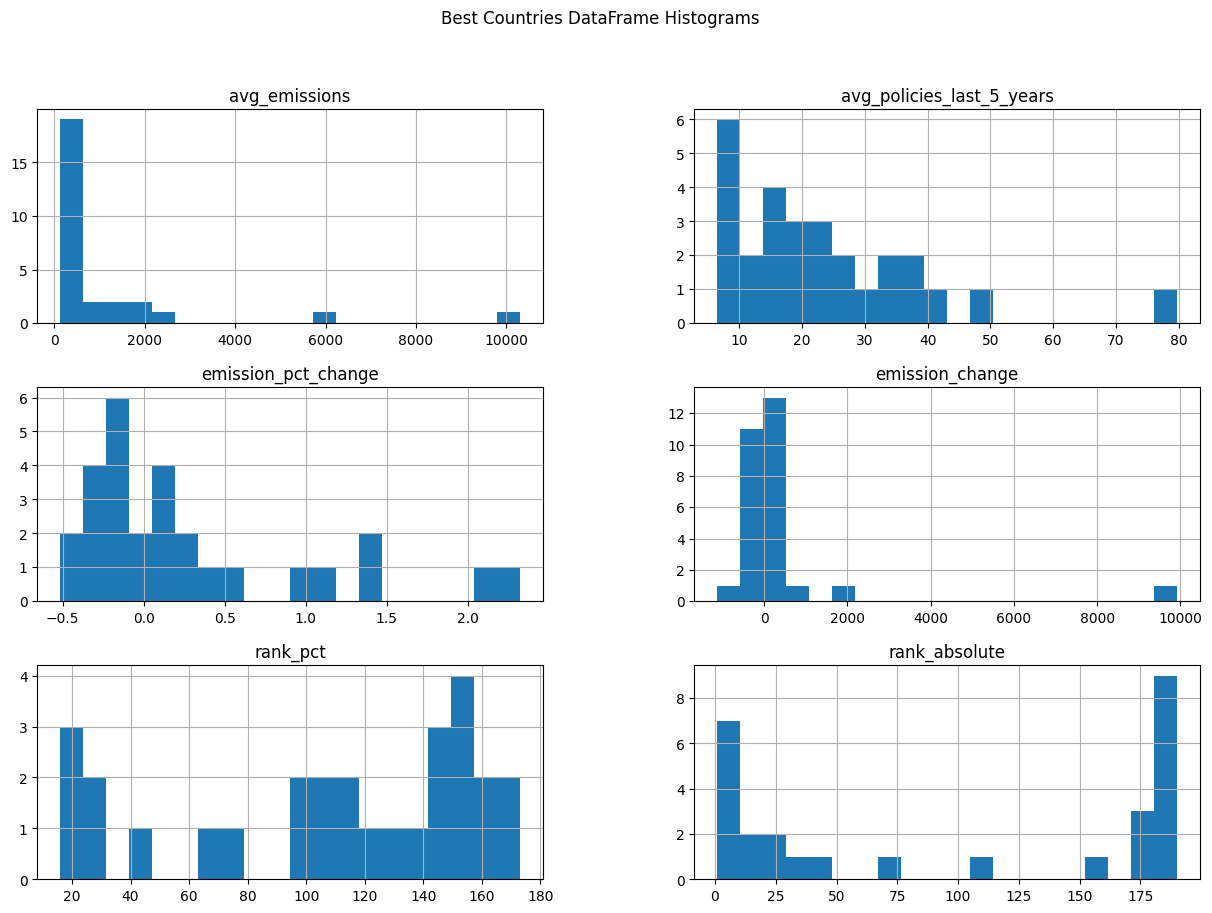

In [199]:
plot_histograms(best_countries_df, 'Best Countries DataFrame Histograms')

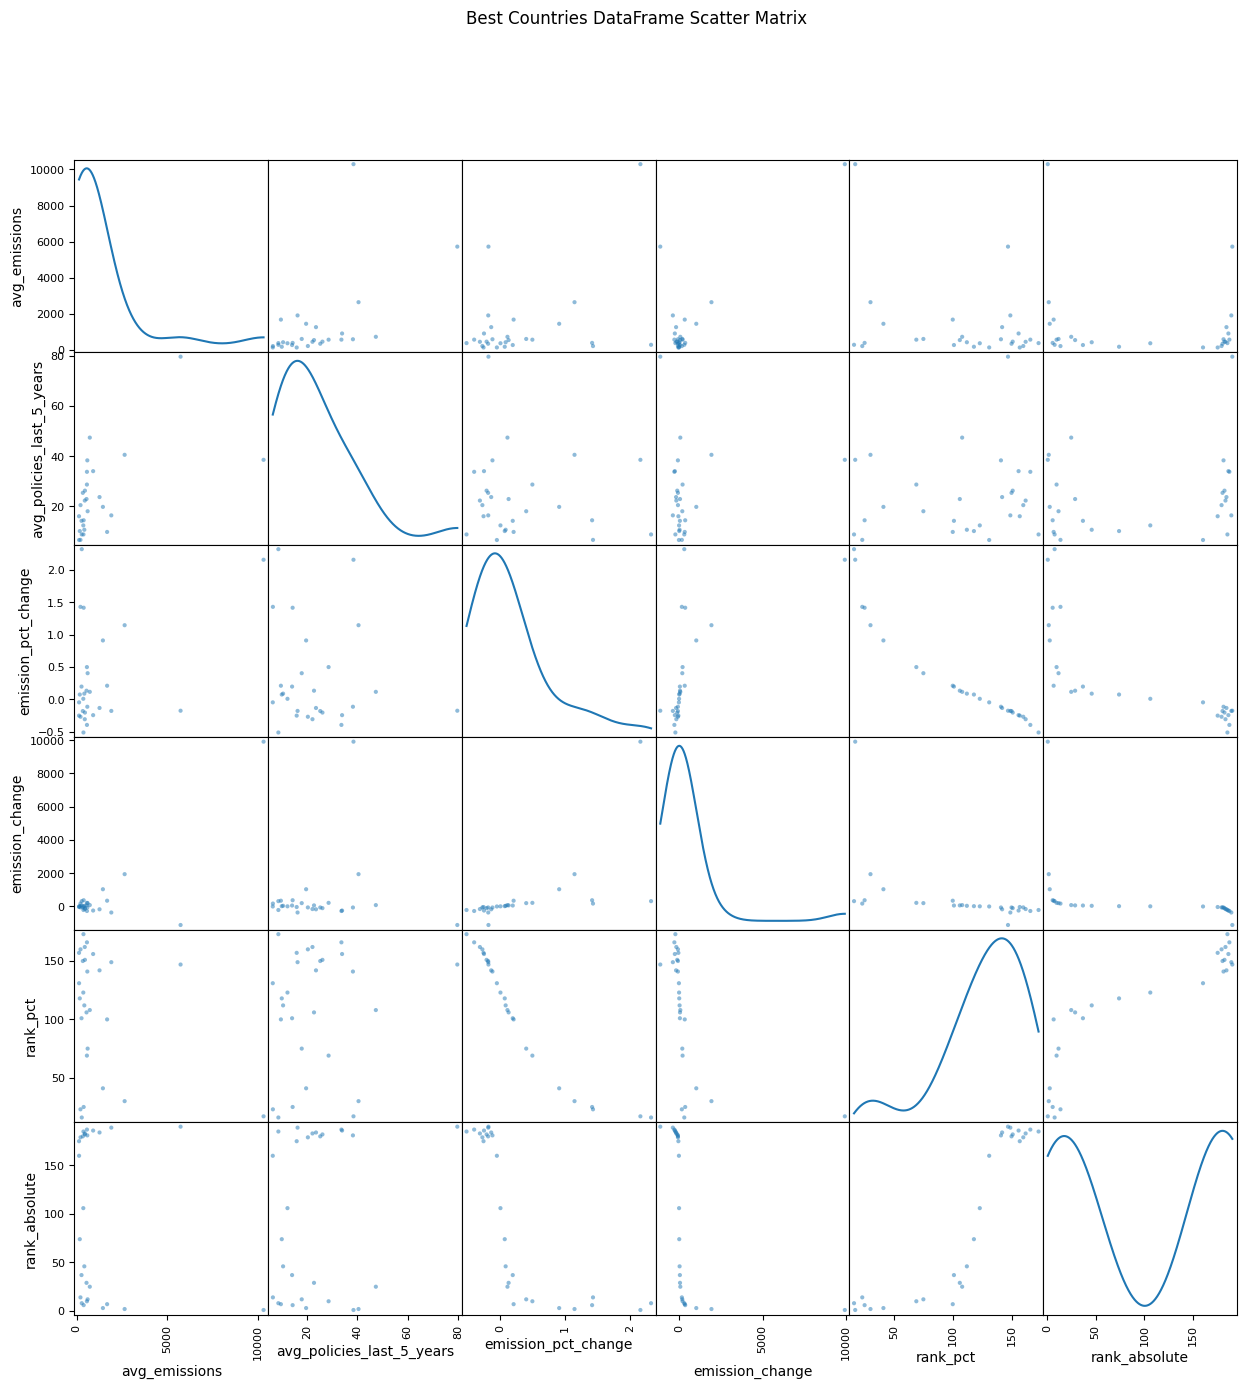

In [200]:
plot_scatter_matrix(best_countries_df, 'Best Countries DataFrame Scatter Matrix')

## Preprocess Data

In [201]:
# Filter the emissions dataset to include only the best countries
best_countries_emissions_df = emissions_total_df[emissions_total_df['iso3'].isin(best_countries)]
# Reset index
best_countries_emissions_df.reset_index(drop=True, inplace=True)
best_countries_emissions_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   iso3                        616 non-null    object 
 1   year                        616 non-null    int64  
 2   country                     616 non-null    object 
 3   policies_last_5_years       616 non-null    float64
 4   income_group                616 non-null    object 
 5   prev_year_emission          616 non-null    float64
 6   avg_emissions_prev_3_years  616 non-null    float64
 7   total_emissions             616 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 38.6+ KB


In [202]:
# Drop iso3 and year columns
best_countries_emissions_df = best_countries_emissions_df.drop(columns=['iso3', 'country'])

In [203]:
# Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Select numeric columns for scaling
numeric_cols = best_countries_emissions_df.select_dtypes(include=['float64', 'int64']).columns

# Remove the 'year' column from the list of numeric columns
if 'year' in numeric_cols:
    numeric_cols = numeric_cols.drop('year')

# Scale the numeric columns
best_countries_emissions_df[numeric_cols] = scaler.fit_transform(best_countries_emissions_df[numeric_cols])

## Define Functions

In [204]:
def time_series_train_test_split(df, target, features, split_year, income_subset=None):
    
    if income_subset:
        test = df[(df.income_group.isin(income_subset)) & (df['year'] > split_year)]
    else:
        test = df[df['year'] > split_year]
    
    train = df[df['year'] <= split_year]

    # Drop year columns
    train = train.drop(columns=['year'])
    test = test.drop(columns=['year'])
    

    print(f"Train shape: {train.shape}")
    print(f"Test shape: {test.shape}")

    print(f'train / test split: {train.shape[0] / df.shape[0]} / {test.shape[0] / df.shape[0]}')

    X_train, y_train = train[features], train[target]
    X_test, y_test = test[features], test[target]

    return X_train, y_train, X_test, y_test


In [205]:

def simple_rf_regressor(X_train, y_train, X_test, y_test):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    print("MAE:", mean_absolute_error(y_test, preds))
    print("R²:", r2_score(y_test, preds))

    # Scatter plot of actual vs predicted
    plt.scatter(y_test, preds)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.show()
    

    return model

In [ ]:
def train_and_test_model(df, target, features, split_year=2017, income_subset=None):
    X_train, y_train, X_test, y_test = time_series_train_test_split(df, target, features, split_year, income_subset)
    model = simple_rf_regressor(X_train, y_train, X_test, y_test)
    importance = pd.Series(model.feature_importances_, index=features)
    print(importance.sort_values(ascending=False))
    importance.sort_values(ascending=False).plot(kind='barh')
    
    return model

## Train Models

In [207]:
best_countries_emissions_df.head()

,year,policies_last_5_years,income_group,prev_year_emission,avg_emissions_prev_3_years,total_emissions
0,2001,-0.912860,High income,-0.505420,-0.511942,-0.493871
1,2002,-0.869658,High income,-0.498912,-0.508591,-0.493392
2,2003,-0.826455,High income,-0.498418,-0.507304,-0.489881
3,2004,-0.826455,High income,-0.494808,-0.503662,-0.486912
4,2005,-0.826455,High income,-0.491755,-0.501206,-0.482714


### Prediction Model

Train shape: (420, 5)
Test shape: (196, 5)
train / test split: 0.6818181818181818 / 0.3181818181818182
MAE: 0.04487655739762991
R²: 0.9869211457953224


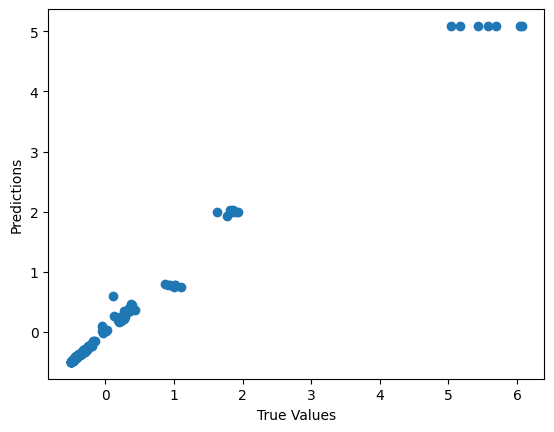

prev_year_emission            0.533150
avg_emissions_prev_3_years    0.462862
policies_last_5_years         0.003988
dtype: float64


RandomForestRegressor(random_state=42)

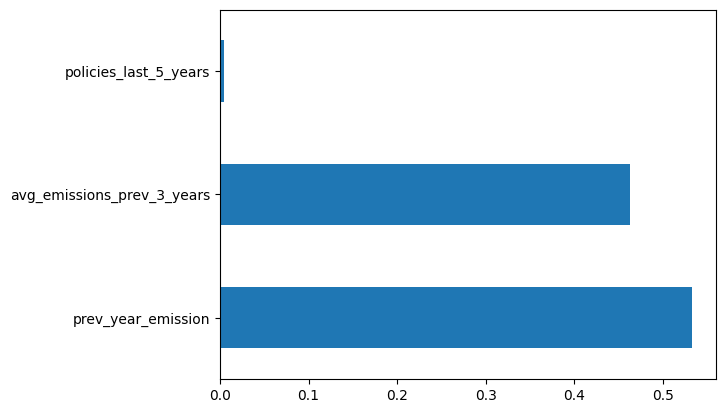

In [213]:
target = 'total_emissions'
features = best_countries_emissions_df.drop(columns=['total_emissions', 'income_group', 'year']).columns
train_and_test_model(best_countries_emissions_df, target, features)

In [214]:
emissions_total_df.income_group.unique()

array(['Low income', 'Lower middle income', 'Upper middle income',
       'High income'], dtype=object)

Train shape: (2850, 7)
Test shape: (175, 7)
train / test split: 0.6818181818181818 / 0.041866028708133975
MAE: 2.0560679844632133
R²: 0.9976140798216371


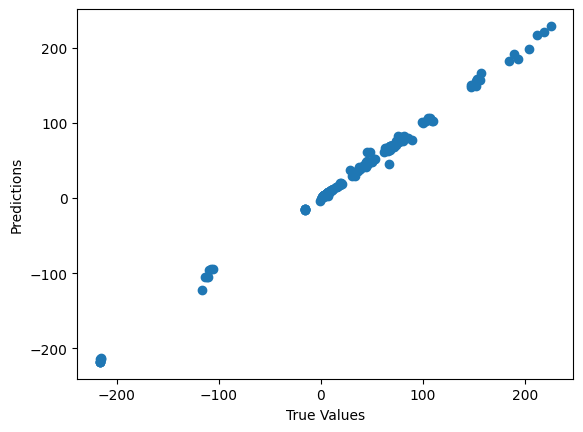

prev_year_emission            0.510975
avg_emissions_prev_3_years    0.485984
policies_last_5_years         0.003041
dtype: float64


RandomForestRegressor(random_state=42)

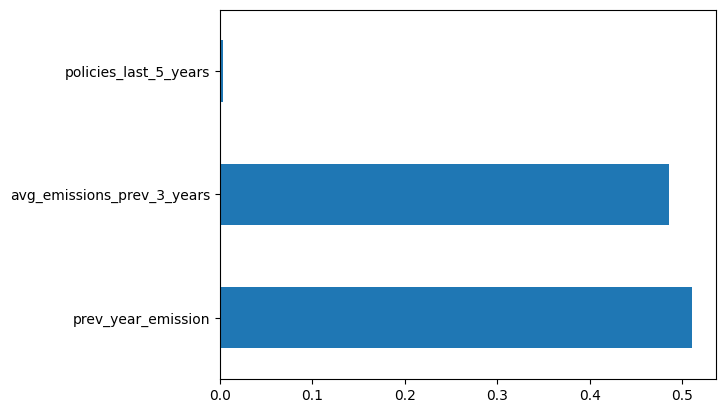

In [215]:
train_and_test_model(emissions_total_df, target, features, income_subset=['Low income'])

Train shape: (3230, 9)
Test shape: (265, 9)
train / test split: 0.7727272727272727 / 0.06339712918660287
MAE: 12.802501413223704
R²: 0.98797546380266


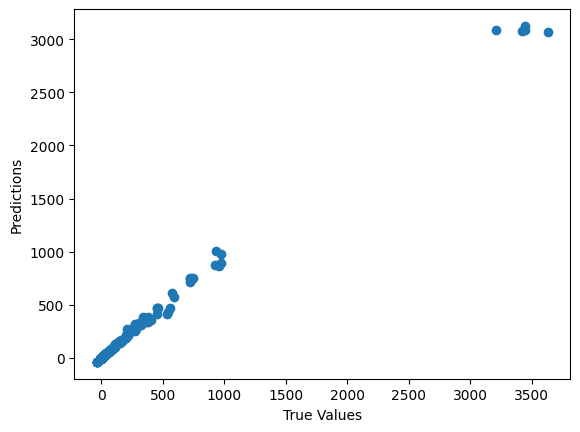

prev_year_emission                    0.560769
avg_emissions_prev_3_years            0.432721
year                                  0.002405
policy_intensity_vs_emission_level    0.001893
policy_trend_lag_interaction          0.001532
policies_last_3_years                 0.000681
dtype: float64


RandomForestRegressor(random_state=42)

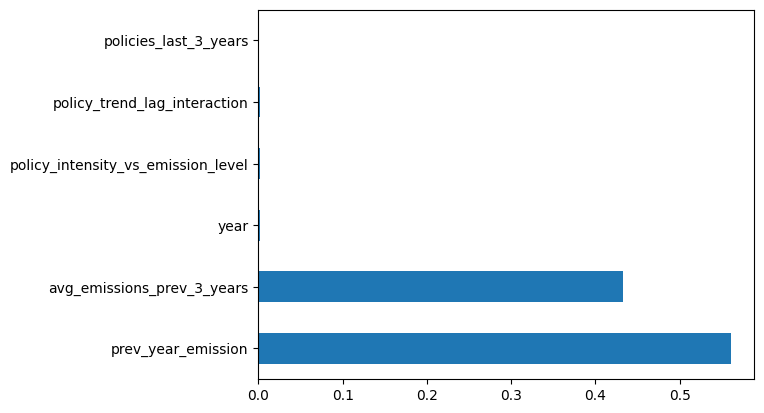

In [35]:
train_and_test_model(emissions_total_df, target, features, income_subset=['Lower middle income'])


Train shape: (3230, 9)
Test shape: (240, 9)
train / test split: 0.7727272727272727 / 0.05741626794258373
MAE: 41.088158836671134
R²: 0.987045833069964


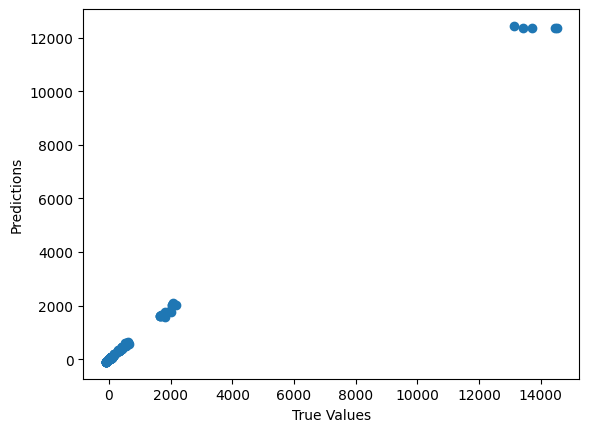

prev_year_emission                    0.560769
avg_emissions_prev_3_years            0.432721
year                                  0.002405
policy_intensity_vs_emission_level    0.001893
policy_trend_lag_interaction          0.001532
policies_last_3_years                 0.000681
dtype: float64


RandomForestRegressor(random_state=42)

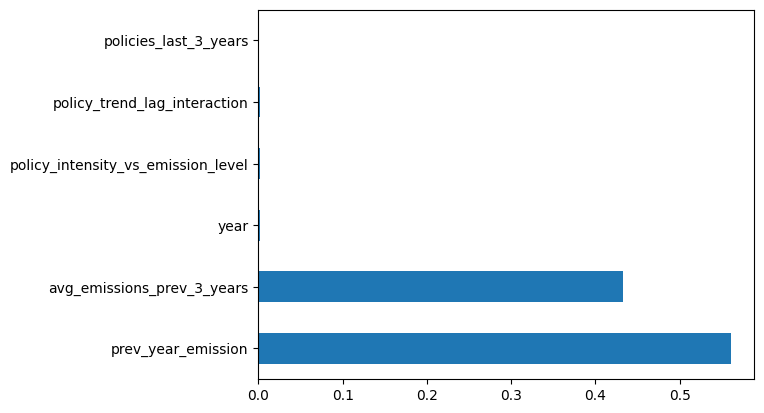

In [36]:
train_and_test_model(emissions_total_df, target, features, income_subset=['Upper middle income'])


Train shape: (3230, 9)
Test shape: (320, 9)
train / test split: 0.7727272727272727 / 0.07655502392344497
MAE: 12.841585612350087
R²: 0.9946362676163895


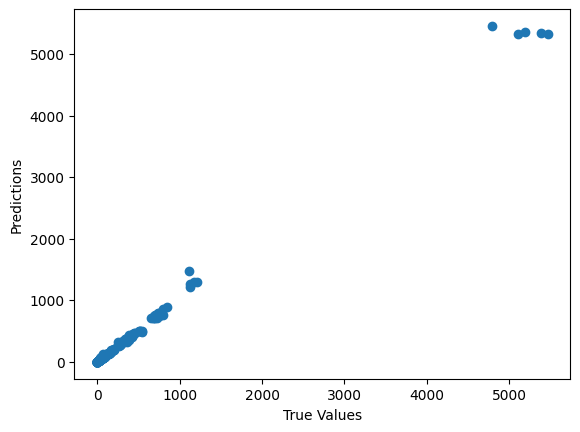

prev_year_emission                    0.560769
avg_emissions_prev_3_years            0.432721
year                                  0.002405
policy_intensity_vs_emission_level    0.001893
policy_trend_lag_interaction          0.001532
policies_last_3_years                 0.000681
dtype: float64


RandomForestRegressor(random_state=42)

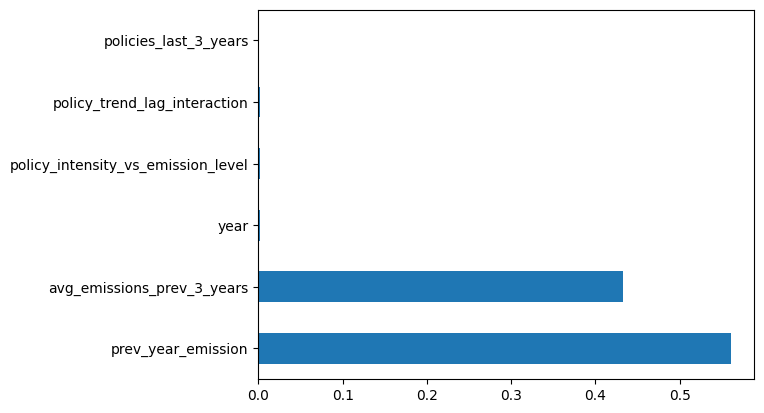

In [37]:
train_and_test_model(emissions_total_df, target, features, income_subset=['High income'])